# Lab 3 — Logistic Regression

**Logistic regression is a classification algorithm** (despite the name). It predicts probabilities
using the sigmoid function, then applies a threshold (default 0.5) to assign class labels.

**Key differences from linear regression:**
- Output is a probability between 0 and 1 (via sigmoid)
- Used for classification, not regression
- Evaluated with accuracy, precision, recall, F1 — not MSE/R²

**Topics covered:**
1. Sigmoid function
2. Binary classification (Shuttle O-rings, Heart Disease)
3. Feature scaling, feature selection
4. Regularisation (C parameter)
5. Multi-class classification (Wine Quality)

---

## Part 1: The Sigmoid Function

Sigmoid squashes any real number into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- When z = 0 → σ = 0.5 (decision boundary)
- When z → +∞ → σ → 1
- When z → −∞ → σ → 0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

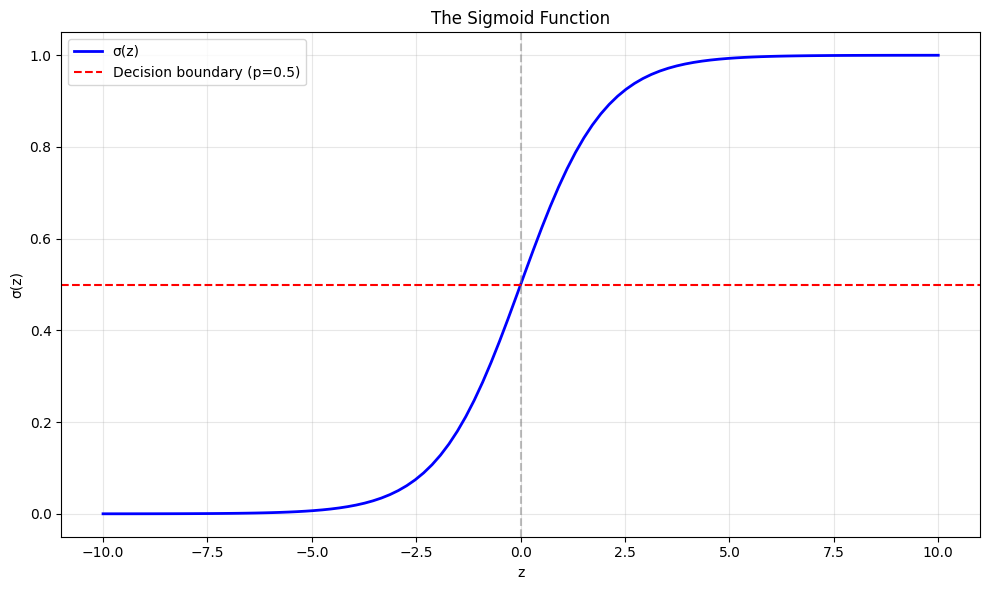

σ(0) = 0.500
σ(-5) = 0.0067  (close to 0)
σ(5) = 0.9933   (close to 1)


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

plt.plot(z, sigmoid(z), 'b-', linewidth=2, label='σ(z)')
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision boundary (p=0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('The Sigmoid Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"σ(0) = {sigmoid(0):.3f}")
print(f"σ(-5) = {sigmoid(-5):.4f}  (close to 0)")
print(f"σ(5) = {sigmoid(5):.4f}   (close to 1)")

---
## Part 2: Binary Classification — Space Shuttle O-Rings

The Challenger disaster (1986): O-rings failed at cold temperatures.
We have data on temperature vs failure (1 = failure, 0 = no failure).
Can we model the probability of failure as a function of temperature?

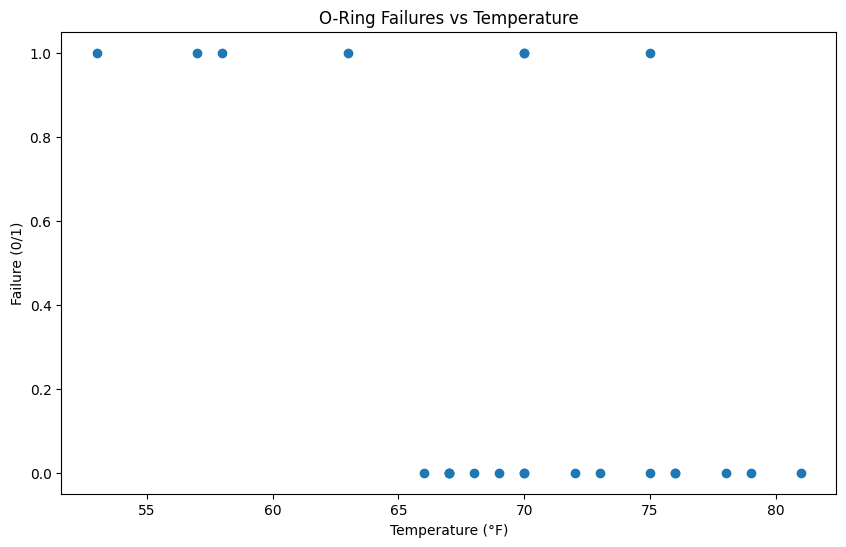

In [3]:
# Load shuttle data
data = np.array([[float(j) for j in e.strip().split()] for e in open('chall.txt')])
dat = pd.DataFrame(data, columns=['Temp', 'Failure'])

plt.scatter(dat['Temp'], dat['Failure'])
plt.xlabel('Temperature (°F)')
plt.ylabel('Failure (0/1)')
plt.title('O-Ring Failures vs Temperature')
plt.show()

### Fit logistic regression

In [4]:
from sklearn.linear_model import LogisticRegression

X = dat['Temp'].values.reshape(-1, 1)  # 2D for sklearn
y = dat['Failure'].values

model = LogisticRegression()
model.fit(X, y)

# .score() for logistic regression gives accuracy (fraction correct)
print(f"Training accuracy: {model.score(X, y):.4f}")

Training accuracy: 0.8696


### .predict() vs .predict_proba()

- `.predict()` returns class labels (0 or 1)
- `.predict_proba()` returns probabilities for each class — shape (n, 2)
  - Column 0 = P(class 0)
  - Column 1 = P(class 1)

For plotting the S-curve, we need `predict_proba`.

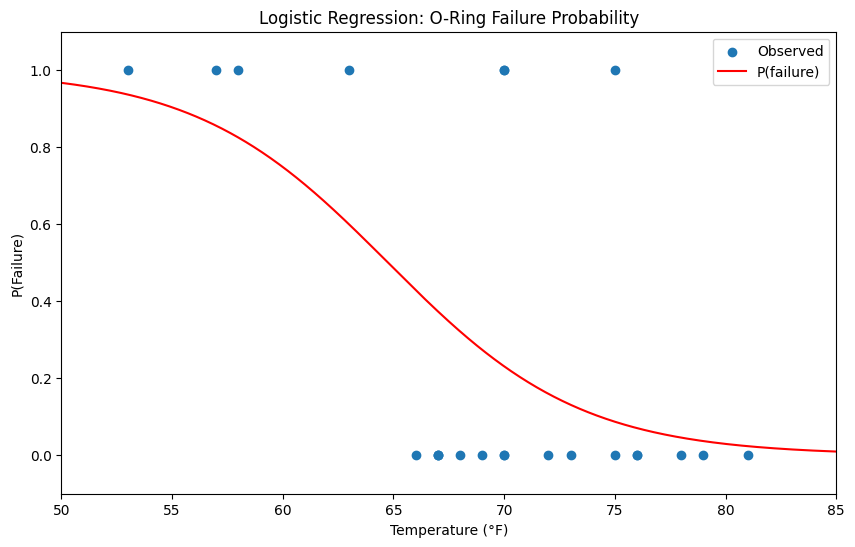

P(failure) at 29°F: 0.9997


In [5]:
x_range = np.linspace(50, 85, 1000).reshape(-1, 1)

# predict_proba gives [P(no fail), P(fail)] for each temperature
y_prob = model.predict_proba(x_range)

# We want P(failure) which is column 1
plt.scatter(dat['Temp'], dat['Failure'], label='Observed')
plt.plot(x_range, y_prob[:, 1], 'r-', label='P(failure)')
plt.xlabel('Temperature (°F)')
plt.ylabel('P(Failure)')
plt.title('Logistic Regression: O-Ring Failure Probability')
plt.xlim(50, 85)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

# At launch temperature (29°F), the model predicts:
launch_temp = np.array([[29]])
print(f"P(failure) at 29°F: {model.predict_proba(launch_temp)[0, 1]:.4f}")

---
## Part 3: Binary Classification — Heart Disease

A more complete example with multiple features, proper train/val split,
feature scaling, and evaluation metrics.

### 3.1 Load and explore

In [6]:
df = pd.read_csv('heart_disease.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['heart_disease'].value_counts())
print(f"\nFirst rows:")
df.head()

Shape: (500, 7)

Columns: ['age', 'cholesterol', 'blood_pressure', 'max_heart_rate', 'exercise_hours', 'bmi', 'heart_disease']

Class distribution:
heart_disease
0    324
1    176
Name: count, dtype: int64

First rows:


,age,cholesterol,blood_pressure,max_heart_rate,exercise_hours,bmi,heart_disease
0,68,325,159,115,7.4,28.5,1
1,58,234,159,170,8.7,37.7,0
2,44,188,93,116,4.3,25.1,0
3,72,249,164,122,0.4,20.8,0
4,37,182,151,125,1.6,28.4,0


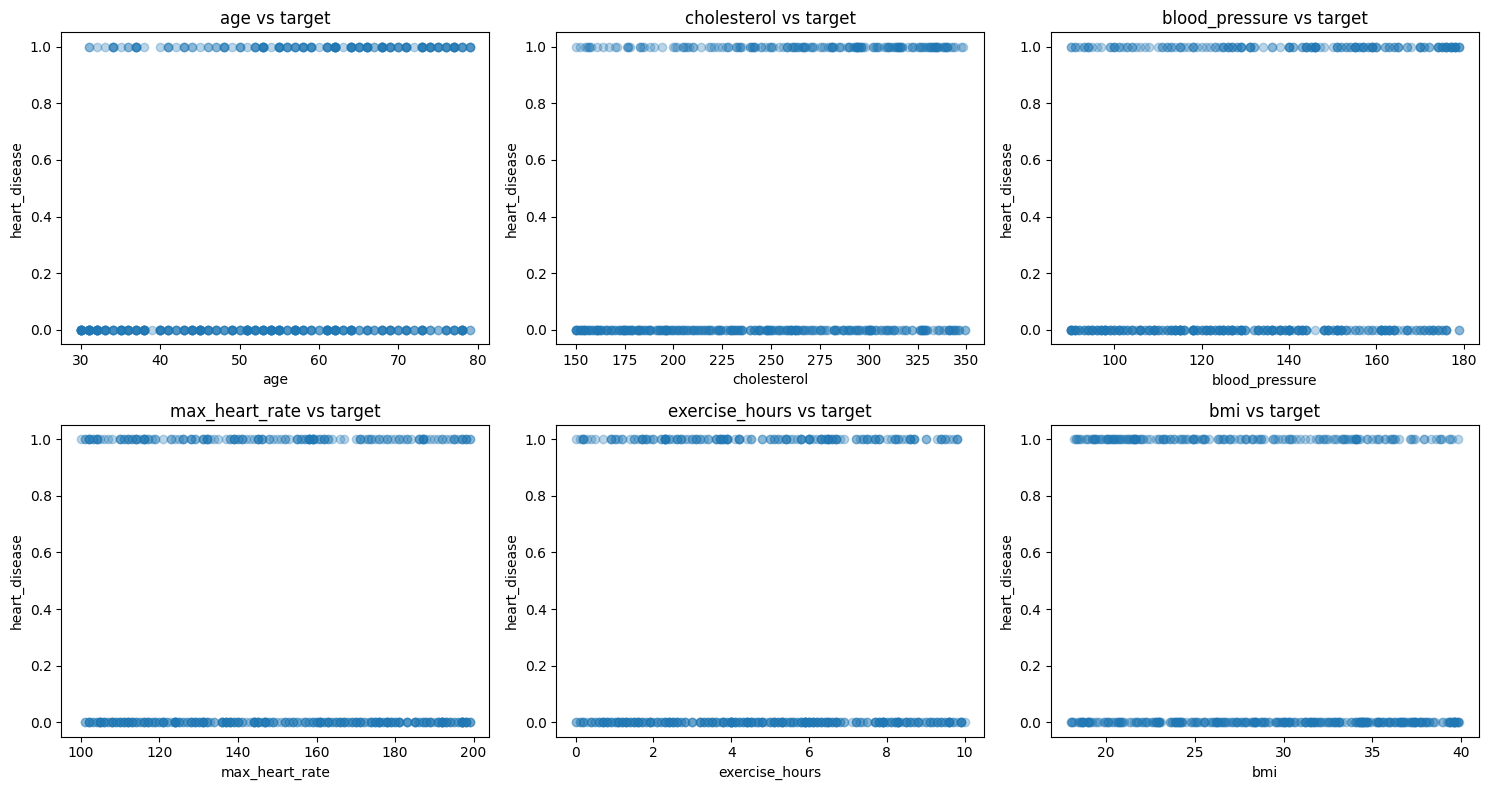

In [7]:
# Scatter plots: each feature vs the target
features = df.columns[:-1]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['heart_disease'], alpha=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('heart_disease')
    ax.set_title(f'{feat} vs target')

plt.tight_layout()
plt.show()

### 3.2 Prepare data — split and scale

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('heart_disease', axis=1).values
y = df['heart_disease'].values

# 80/20 train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.3 Feature scaling

Logistic regression uses gradient-based optimisation. Features on different scales
make convergence slower and can hurt performance.

**Important:** fit the scaler on training data only, then transform both train and val.
This prevents information leaking from the validation set into training.

In [9]:
scaler = StandardScaler()

# fit_transform on training: learns mean/std, then scales
X_train_scaled = scaler.fit_transform(X_train)

# transform only on validation: uses the training mean/std
X_val_scaled = scaler.transform(X_val)

print(f"Training: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")

Training: (400, 6)
Validation: (100, 6)


### 3.4 Train logistic regression

In [10]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 3.5 Evaluate

**Classification metrics:**
- **Accuracy** = fraction of correct predictions
- **Precision** = of those predicted positive, how many were actually positive
- **Recall** = of those actually positive, how many did we catch
- **F1** = harmonic mean of precision and recall

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_val_pred = model.predict(X_val_scaled)

print(f"Validation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print(f"Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.7400

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        69
           1       0.57      0.65      0.61        31

    accuracy                           0.74       100
   macro avg       0.70      0.71      0.71       100
weighted avg       0.75      0.74      0.74       100

Confusion Matrix:
[[54 15]
 [11 20]]


### 3.6 Visualise coefficients

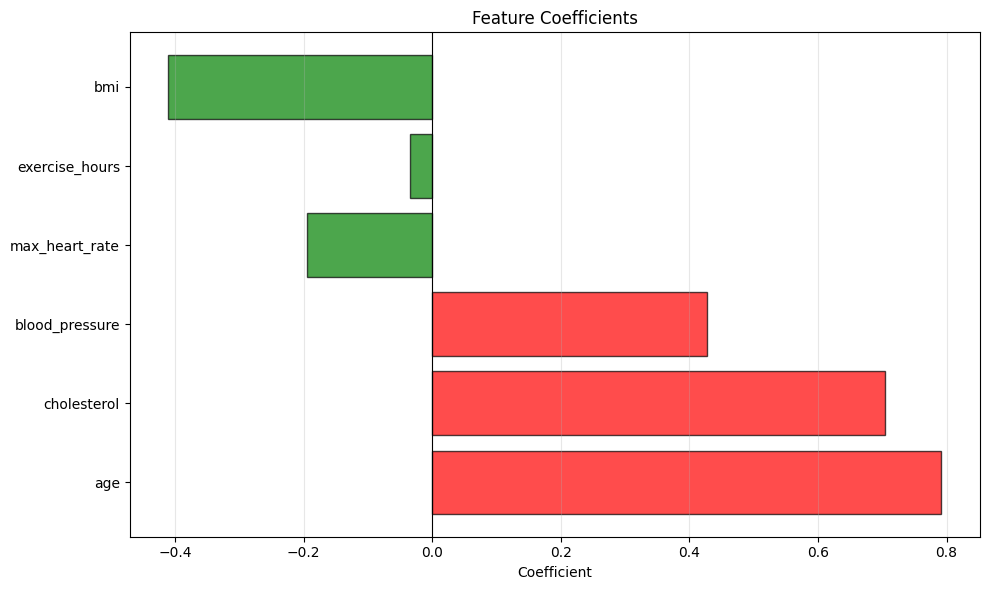

In [12]:
feature_names = df.drop('heart_disease', axis=1).columns
coefficients = model.coef_[0]

# Horizontal bar chart — positive = increases P(disease), negative = decreases
colors = ['red' if c > 0 else 'green' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Positive coefficient → increases probability of heart disease
# Negative coefficient → decreases probability of heart disease

---
## Part 4: Feature Selection Using the Validation Set

Not all features help. Adding irrelevant features can hurt performance.
Forward selection: start with nothing, add the feature that helps most, repeat.

### 4.1 Forward feature selection

In [13]:
# Forward selection: greedily add the best feature at each step
all_features = list(range(X_train_scaled.shape[1]))
selected = []
accuracy_history = []

for step in range(len(all_features)):
    best_acc = 0
    best_feat = None

    # Try adding each remaining feature
    for feat in all_features:
        if feat in selected:
            continue
        trial = selected + [feat]
        m = LogisticRegression()
        m.fit(X_train_scaled[:, trial], y_train)
        acc = m.score(X_val_scaled[:, trial], y_val)
        if acc > best_acc:
            best_acc = acc
            best_feat = feat

    selected.append(best_feat)
    accuracy_history.append(best_acc)
    print(f"Step {step+1}: added feature {feature_names[best_feat]:>20s} → val accuracy = {best_acc:.4f}")

print(f"\nBest subset: {[feature_names[i] for i in selected[:np.argmax(accuracy_history)+1]]}")
print(f"Best accuracy: {max(accuracy_history):.4f}")

Step 1: added feature       blood_pressure → val accuracy = 0.7300
Step 2: added feature       exercise_hours → val accuracy = 0.7300
Step 3: added feature       max_heart_rate → val accuracy = 0.7300
Step 4: added feature                  age → val accuracy = 0.7000
Step 5: added feature          cholesterol → val accuracy = 0.6900
Step 6: added feature                  bmi → val accuracy = 0.7400

Best subset: ['blood_pressure', 'exercise_hours', 'max_heart_rate', 'age', 'cholesterol', 'bmi']
Best accuracy: 0.7400


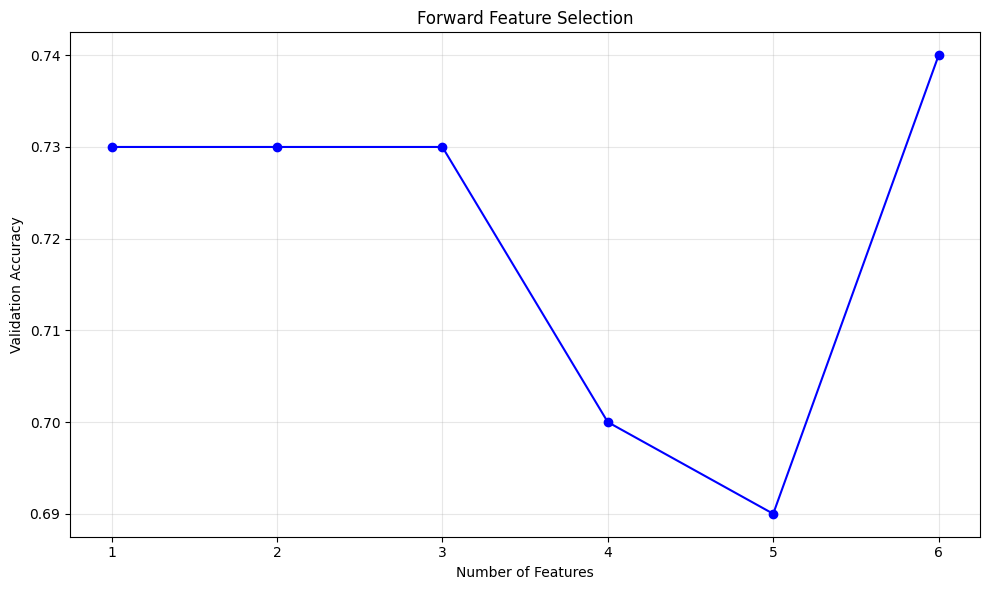

In [14]:
plt.plot(range(1, len(accuracy_history)+1), accuracy_history, 'bo-')
plt.xlabel('Number of Features')
plt.ylabel('Validation Accuracy')
plt.title('Forward Feature Selection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 5: Regularisation (C parameter)

Regularisation penalises large coefficients to prevent overfitting.

In sklearn's `LogisticRegression`, the `C` parameter controls this:
- **Large C** (e.g. 100) → weak regularisation → complex model, risk of overfitting
- **Small C** (e.g. 0.01) → strong regularisation → simpler model, risk of underfitting

C is the *inverse* of regularisation strength.

### 5.1 Find the best C value

In [15]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_accuracies = []
val_accuracies = []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    train_accuracies.append(m.score(X_train_scaled, y_train))
    val_accuracies.append(m.score(X_val_scaled, y_val))

# Print results
for C, tr, va in zip(C_values, train_accuracies, val_accuracies):
    print(f"C={C:<8} Train: {tr:.4f}  Val: {va:.4f}")

best_C = C_values[np.argmax(val_accuracies)]
print(f"\nBest C: {best_C} (val accuracy: {max(val_accuracies):.4f})")

C=0.001    Train: 0.6375  Val: 0.6900
C=0.01     Train: 0.6600  Val: 0.7600
C=0.1      Train: 0.7400  Val: 0.7600
C=1        Train: 0.7300  Val: 0.7400
C=10       Train: 0.7300  Val: 0.7400
C=100      Train: 0.7275  Val: 0.7400

Best C: 0.01 (val accuracy: 0.7600)


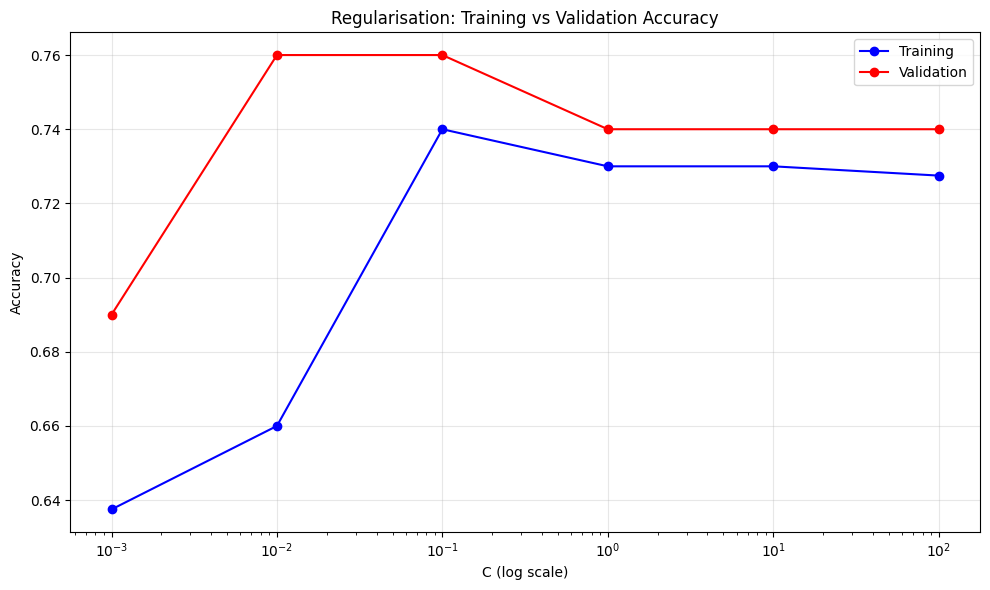

In [16]:
plt.plot(C_values, train_accuracies, 'bo-', label='Training')
plt.plot(C_values, val_accuracies, 'ro-', label='Validation')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Regularisation: Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gap between train and val = overfitting
# Both low = underfitting

### 5.2 How regularisation affects coefficients

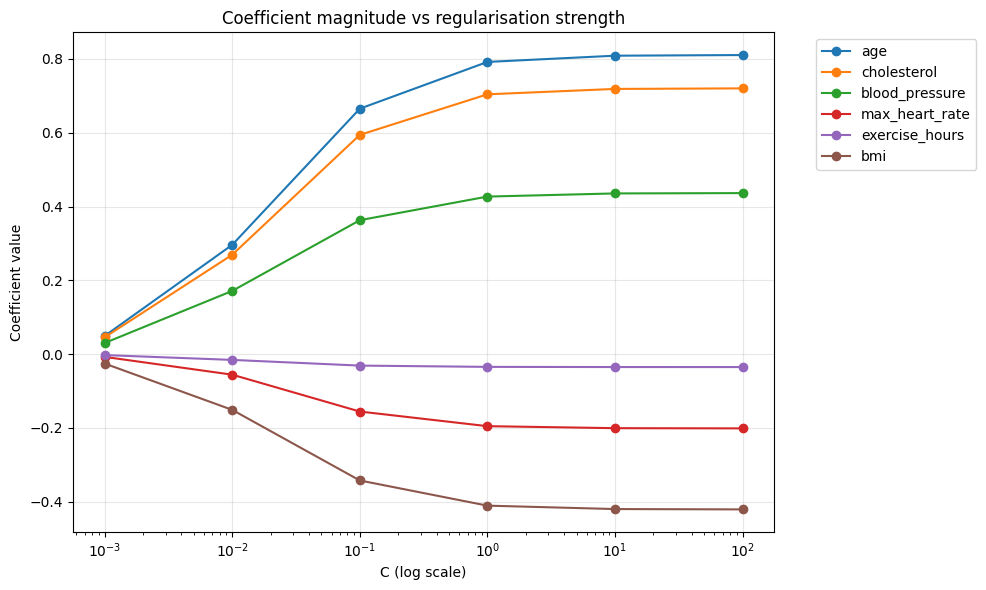

In [17]:
# Track how coefficients change with C
coef_matrix = []
for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    coef_matrix.append(m.coef_[0])

coef_matrix = np.array(coef_matrix)

plt.figure(figsize=(10, 6))
for i, name in enumerate(feature_names):
    plt.plot(C_values, coef_matrix[:, i], 'o-', label=name)

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Coefficient value')
plt.title('Coefficient magnitude vs regularisation strength')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Small C → coefficients shrink towards 0 (strong regularisation)
# Large C → coefficients are unconstrained

### 5.3 Train final model with best C

In [18]:
# Combine train + val for the final model (use all available labelled data)
X_final = np.vstack([X_train_scaled, X_val_scaled])
y_final = np.concatenate([y_train, y_val])

final_model = LogisticRegression(C=best_C, max_iter=1000)
final_model.fit(X_final, y_final)

print(f"Final model trained with C={best_C}")
print(f"Training accuracy (on combined set): {final_model.score(X_final, y_final):.4f}")

Final model trained with C=0.01
Training accuracy (on combined set): 0.6840


---
## Part 6: Multi-class Classification — Wine Quality

Logistic regression extends to multi-class via:
- **One-vs-Rest (OVR):** trains one binary classifier per class
- **Multinomial:** models all classes simultaneously with softmax

sklearn handles this automatically.

### 6.1 Load and explore

In [19]:
wine_df = pd.read_csv('wine_quality.csv')

print(f"Shape: {wine_df.shape}")
print(f"\nClass distribution:")
print(wine_df['quality'].value_counts().sort_index())
wine_df.head()

Shape: (600, 7)

Class distribution:
quality
High       86
Low       105
Medium    409
Name: count, dtype: int64


,alcohol,acidity,residual_sugar,pH,sulphates,density,quality
0,14.35,4.03,1.77,2.82,0.34,0.9930,Medium
1,8.11,4.38,1.45,3.88,0.70,1.0088,Low
2,13.48,2.53,13.42,2.88,0.92,0.9937,High
3,8.87,3.55,7.23,3.99,1.26,1.0013,Low
4,13.58,3.44,5.14,3.94,0.71,0.9975,High


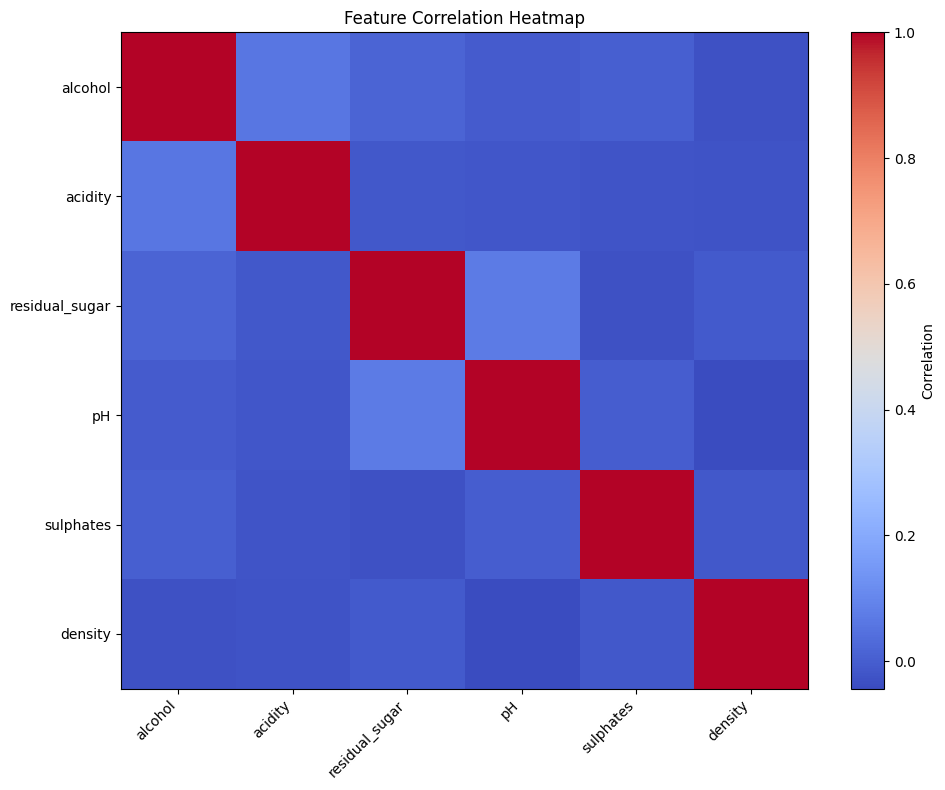

In [20]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = wine_df.corr(numeric_only=True)
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label='Correlation')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### 6.2 Prepare data — 60/20/20 split

In [21]:
# Separate features and target
X_wine = wine_df.drop('quality', axis=1).values
y_wine = wine_df['quality'].values

# First split: 60% train, 40% temp
X_wine_train, X_wine_temp, y_wine_train, y_wine_temp = train_test_split(
    X_wine, y_wine, test_size=0.4, random_state=42
)

# Second split: split the 40% into 20% val + 20% test
X_wine_val, X_wine_test, y_wine_val, y_wine_test = train_test_split(
    X_wine_temp, y_wine_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_wine_train.shape[0]}, Val: {X_wine_val.shape[0]}, Test: {X_wine_test.shape[0]}")

# Scale
wine_scaler = StandardScaler()
X_wine_train_sc = wine_scaler.fit_transform(X_wine_train)
X_wine_val_sc = wine_scaler.transform(X_wine_val)
X_wine_test_sc = wine_scaler.transform(X_wine_test)

Train: 360, Val: 120, Test: 120


### 6.3 Train multi-class model

In [22]:
# Multi-class is handled automatically by current scikit-learn versions
wine_model = LogisticRegression(max_iter=1000)
wine_model.fit(X_wine_train_sc, y_wine_train)

print(f"Train accuracy: {wine_model.score(X_wine_train_sc, y_wine_train):.4f}")
print(f"Val accuracy:   {wine_model.score(X_wine_val_sc, y_wine_val):.4f}")

Train accuracy: 0.7194
Val accuracy:   0.7333


### 6.4 Evaluate with classification report and confusion matrix

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.33      0.48        15
         Low       0.14      0.06      0.09        16
      Medium       0.77      0.92      0.84        89

    accuracy                           0.73       120
   macro avg       0.58      0.44      0.47       120
weighted avg       0.69      0.73      0.69       120



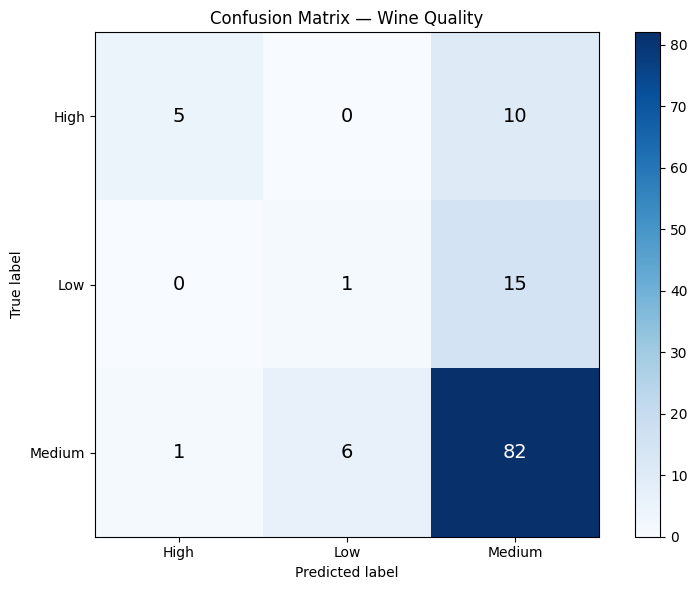

In [23]:
y_wine_val_pred = wine_model.predict(X_wine_val_sc)

print("Classification Report:")
print(classification_report(y_wine_val, y_wine_val_pred))

# Confusion matrix
cm = confusion_matrix(y_wine_val, y_wine_val_pred)
classes = sorted(np.unique(y_wine))

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix — Wine Quality')
plt.colorbar()
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

# Annotate cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black', fontsize=14)

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

### 6.5 Regularisation tuning for multi-class

In [24]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
wine_train_acc = []
wine_val_acc = []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=1000)
    m.fit(X_wine_train_sc, y_wine_train)
    wine_train_acc.append(m.score(X_wine_train_sc, y_wine_train))
    wine_val_acc.append(m.score(X_wine_val_sc, y_wine_val))

for C, tr, va in zip(C_values, wine_train_acc, wine_val_acc):
    print(f"C={C:<8} Train: {tr:.4f}  Val: {va:.4f}")

best_wine_C = C_values[np.argmax(wine_val_acc)]
print(f"\nBest C: {best_wine_C}")

C=0.001    Train: 0.6611  Val: 0.7417
C=0.01     Train: 0.6611  Val: 0.7417
C=0.1      Train: 0.7167  Val: 0.7167
C=1        Train: 0.7194  Val: 0.7333
C=10       Train: 0.7111  Val: 0.7333
C=100      Train: 0.7139  Val: 0.7333

Best C: 0.001


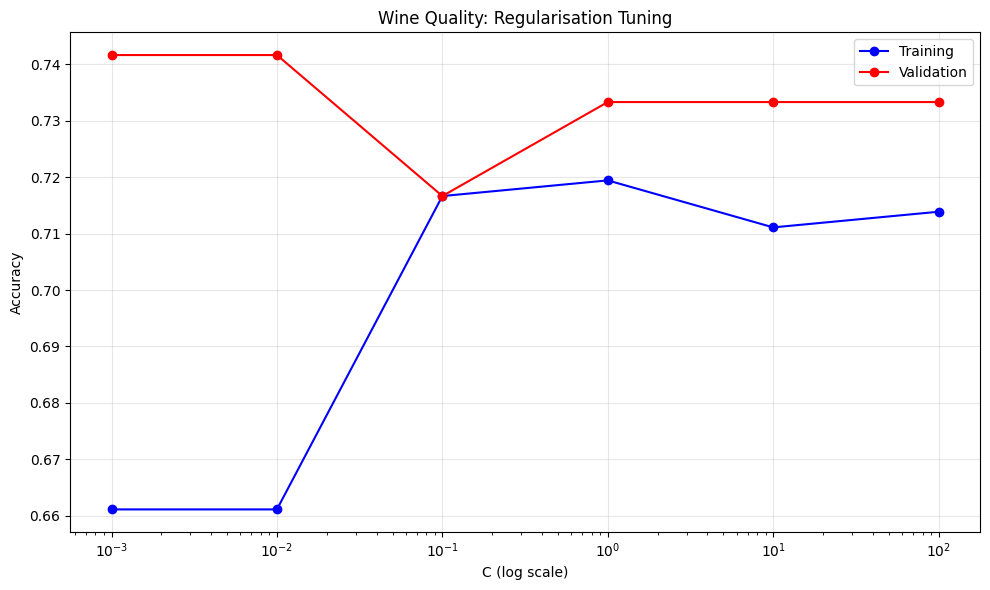

In [25]:
plt.plot(C_values, wine_train_acc, 'bo-', label='Training')
plt.plot(C_values, wine_val_acc, 'ro-', label='Validation')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('Wine Quality: Regularisation Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Final model — retrain and evaluate on test set

In [26]:
# Combine train + val, retrain with best C, evaluate on held-out test set
X_wine_final = np.vstack([X_wine_train_sc, X_wine_val_sc])
y_wine_final = np.concatenate([y_wine_train, y_wine_val])

final_wine = LogisticRegression(C=best_wine_C, max_iter=1000)
final_wine.fit(X_wine_final, y_wine_final)

test_pred = final_wine.predict(X_wine_test_sc)
print(f"Test accuracy: {accuracy_score(y_wine_test, test_pred):.4f}")
print(f"\nTest Classification Report:")
print(classification_report(y_wine_test, test_pred))

Test accuracy: 0.6833

Test Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        20
         Low       0.00      0.00      0.00        18
      Medium       0.68      1.00      0.81        82

    accuracy                           0.68       120
   macro avg       0.23      0.33      0.27       120
weighted avg       0.47      0.68      0.55       120



/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/ML_Labs/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

---
## Summary

### Logistic Regression
```python
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

# Train
model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train_sc, y_train)

# Predict
y_pred = model.predict(X_val_sc)          # class labels
y_prob = model.predict_proba(X_val_sc)    # probabilities (n, n_classes)

# Evaluate
print(accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

# Inspect
model.coef_        # coefficients (positive = increases P(class 1))
model.intercept_   # bias
```

### Classification Metrics
| Metric | Meaning |
|--------|---------|
| Accuracy | Fraction correct overall |
| Precision | Of predicted positives, how many are correct |
| Recall | Of actual positives, how many did we find |
| F1 | Harmonic mean of precision and recall |

### Feature Scaling
- Always scale for logistic regression
- `fit_transform` on train, `transform` on val/test
- Never fit the scaler on validation or test data

### Regularisation (C parameter)
- Small C → strong regularisation → simpler model → risk underfitting
- Large C → weak regularisation → complex model → risk overfitting
- Tune C using validation accuracy, not training accuracy

### Multi-class
- In current sklearn versions, multi-class handling is automatic
- Use `OneVsRestClassifier(LogisticRegression(...))` only if you need explicit OVR
- Evaluate with confusion matrix and per-class precision/recall

### .predict() vs .predict_proba()
- `.predict()` → class labels (0, 1, 2...)
- `.predict_proba()` → probability array, shape (n_samples, n_classes)
- Column index = class label